In [54]:
import pandas as pd
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df = pd.read_csv("../data/raw/dataset.csv")

## Data Cleaning

In [41]:
df_clean = df.copy()

In [42]:
df_clean = df_clean.dropna(subset=['CREDIT_LIMIT'])

In [43]:
df_clean = df_clean.drop_duplicates()

In [44]:
df_clean.shape

(8949, 8)

### Save the df_clean before transformation

In [45]:
df_clean.to_csv("../data/processed/df_clean.csv", index=False)

## Data Preprocessing

In [46]:
df_prepare_clustering = df_clean.copy()

In [47]:
cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

### Log transform

In [48]:
df_clean[df_clean[['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']] < 0]

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
8945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
for col in cols:
    df_prepare_clustering[col] = np.log1p(df_prepare_clustering[col])

In [50]:
df_prepare_clustering.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231
1,C10002,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725
2,C10003,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654
3,C10004,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000
4,C10005,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114


### Before/after skewness table

In [51]:
skew_before = df_clean[cols].apply(skew)
skew_after = df_prepare_clustering[cols].apply(skew)

skew_comparison = pd.DataFrame({
    "skew_before": skew_before,
    "skew_after": skew_after
})
skew_comparison

,skew_before,skew_after
BALANCE,2.392869,-0.861277
PURCHASES,8.142604,-0.764716
ONEOFF_PURCHASES,10.042938,0.185619
INSTALLMENTS_PURCHASES,7.297600,-0.025202
CASH_ADVANCE,5.165457,0.262711
CREDIT_LIMIT,1.522209,-0.101421
PAYMENTS,5.906475,-1.778786


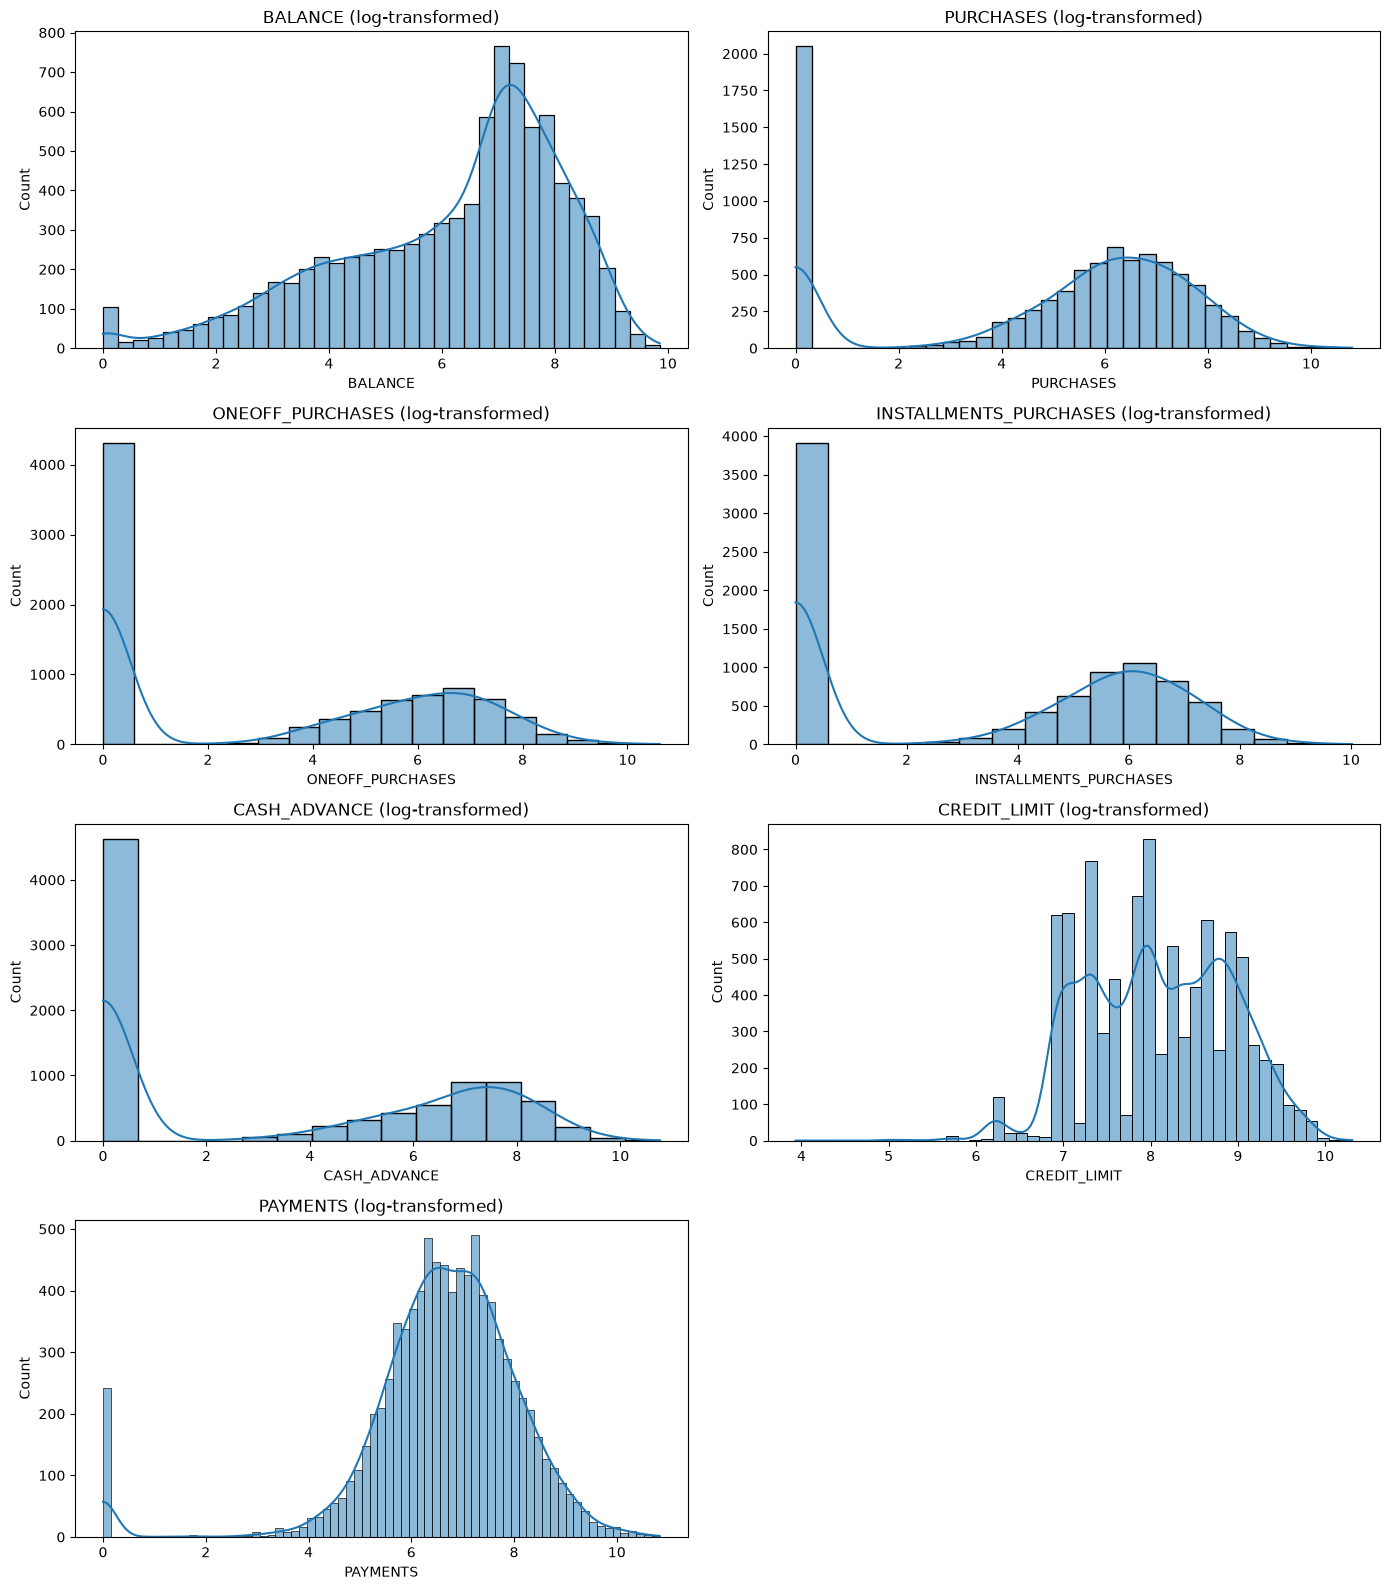

In [52]:

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_prepare_clustering[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log-transformed)")

axes[7].axis("off")
plt.tight_layout()
plt.show()

### Standard Scalling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_prepare_clustering[cols] = scaler.fit_transform(df_prepare_clustering[cols])

df_prepare_clustering[cols].describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8.949000e+03,8.949000e+03,8.949000e+03,8.949000e+03,8.949000e+03,8.949000e+03,8.949000e+03
mean,1.397425e-16,6.351930e-17,-7.622316e-17,3.652360e-17,2.540772e-17,3.557081e-16,-2.540772e-17
std,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-3.061071e+00,-1.680213e+00,-9.871985e-01,-1.087586e+00,-9.306359e-01,-5.079142e+00,-4.163779e+00
25%,-6.454735e-01,-4.085542e-01,-9.871985e-01,-1.087586e+00,-9.306359e-01,-8.741168e-01,-4.233803e-01
50%,3.039534e-01,3.404191e-01,1.413749e-01,3.720783e-01,-9.306359e-01,-1.075291e-01,8.148696e-02
75%,7.283677e-01,7.245116e-01,9.723332e-01,9.080179e-01,1.036840e+00,8.355939e-01,5.818495e-01
max,1.834319e+00,2.023105e+00,2.282948e+00,2.163164e+00,2.086782e+00,2.701408e+00,2.645391e+00


### PCA

In [55]:
pca_full = PCA()
pca_full.fit(df_prepare_clustering[cols])

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: explained = {var:.4f}, cumulative = {cum:.4f}")

PC1: explained = 0.3536, cumulative = 0.3536
PC2: explained = 0.2926, cumulative = 0.6462
PC3: explained = 0.1140, cumulative = 0.7602
PC4: explained = 0.1001, cumulative = 0.8602
PC5: explained = 0.0763, cumulative = 0.9365
PC6: explained = 0.0497, cumulative = 0.9862
PC7: explained = 0.0138, cumulative = 1.0000


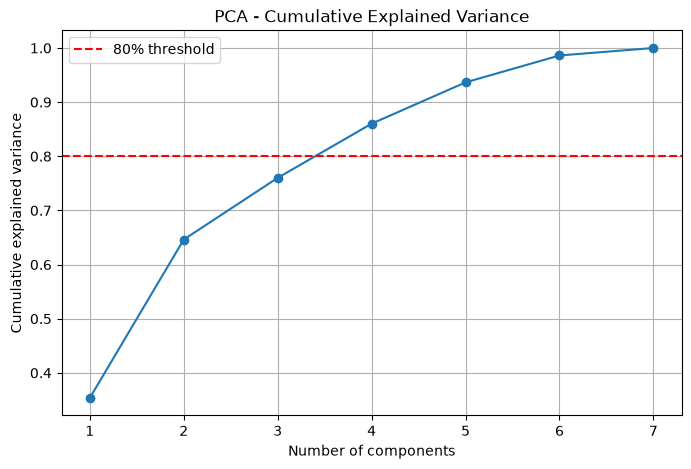

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o")
plt.axhline(y=0.80, color="r", linestyle="--", label="80% threshold")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Components needed for 80% variance: {n_components_80}")

Components needed for 80% variance: 4
